# 📈 Sales & Demand Forecasting (Task-01)
## Store Item Demand Forecasting (Kaggle)

### ✅ Objective
Build a model to **forecast future sales/demand** using historical daily sales data.

### ✅ Dataset
We are using the Kaggle competition dataset:
- `train.csv` → historical sales (daily)
- `test.csv` → future dates to predict
- `sample_submission.csv` → submission format

### ✅ What we will do
1. Load and understand the data  
2. Clean and preprocess  
3. Feature Engineering (time-based features + lag features)  
4. Train forecasting model  
5. Evaluate using time-based split (MAE / RMSE)  
6. Forecast future sales and create predictions for test data  
7. Visualize results (actual vs predicted)

## 🔧 Step 1: Import Required Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

## 📥 Step 2: Load Dataset Files
Make sure the 3 CSV files are in the same folder as this notebook (or update the file paths).

In [2]:
train_path = "train.csv"
test_path = "test.csv"
sub_path = "sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sub = pd.read_csv(sub_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", sub.shape)

train.head()

Train shape: (913000, 4)
Test shape: (45000, 4)
Submission shape: (45000, 2)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 🧾 Step 3: Quick Data Check (Info + Missing Values)

In [3]:
train.info(), test.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      45000 non-null  int64
 1   date    45000 non-null  str  
 2   store   45000 non-null  int64
 3   item    45000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.4 MB


(None, None)

In [4]:
print("Missing values in train:\n", train.isna().sum())
print("\nMissing values in test:\n", test.isna().sum())

Missing values in train:
 date     0
store    0
item     0
sales    0
dtype: int64

Missing values in test:
 id       0
date     0
store    0
item     0
dtype: int64


## 🗓️ Step 4: Convert `date` Column to Datetime
Time-series forecasting always needs proper datetime format.

In [5]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

train.dtypes

date     datetime64[us]
store             int64
item              int64
sales             int64
dtype: object

## 📊 Step 5: Exploratory Data Analysis (EDA)
### 5.1 Total Sales Trend Over Time
We aggregate sales by date to see the overall demand pattern.

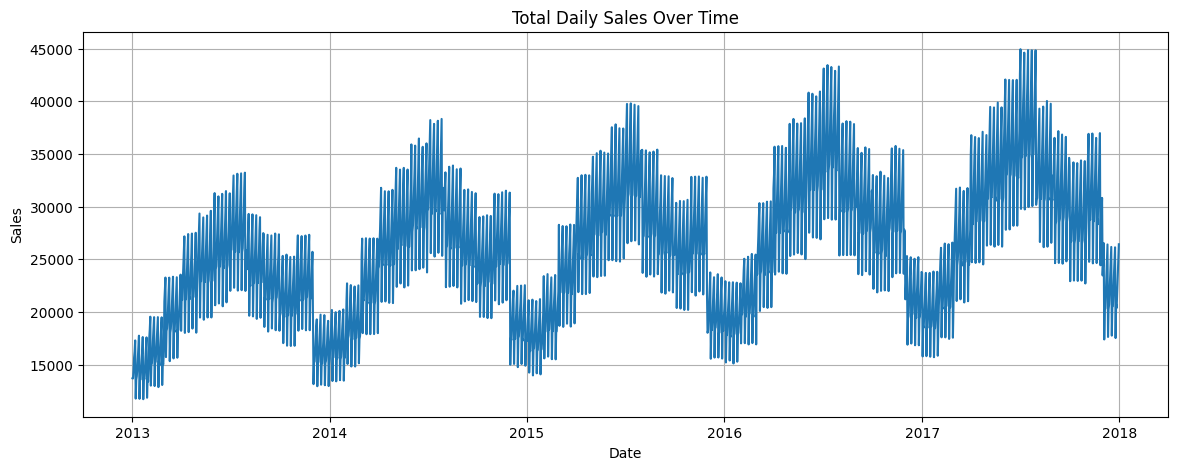

In [6]:
daily_sales = train.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## 🧠 Step 6: Feature Engineering (Time-based Features)
We'll extract features from date:
- year, month, day
- day of week
- weekend flag

In [7]:
def add_time_features(df):
    df = df.copy()
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek  # Monday=0
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    return df

train_fe = add_time_features(train)
test_fe = add_time_features(test)

train_fe.head()

,date,store,item,sales,year,month,day,dayofweek,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,0
1,2013-01-02,1,1,11,2013,1,2,2,0
2,2013-01-03,1,1,14,2013,1,3,3,0
3,2013-01-04,1,1,13,2013,1,4,4,0
4,2013-01-05,1,1,10,2013,1,5,5,1


## 🔁 Step 7: Lag Features (Previous Day Sales)
Lag features help models learn from past sales patterns.

We'll create:
- lag_1  (yesterday)
- lag_7  (last week)
- rolling_mean_7 (7-day average)

In [8]:
train_fe = train_fe.sort_values(["store", "item", "date"])

train_fe["lag_1"] = train_fe.groupby(["store","item"])["sales"].shift(1)
train_fe["lag_7"] = train_fe.groupby(["store","item"])["sales"].shift(7)
train_fe["roll_mean_7"] = train_fe.groupby(["store","item"])["sales"].shift(1).rolling(7).mean()

train_fe.head(10)

,date,store,item,sales,year,month,day,dayofweek,is_weekend,lag_1,lag_7,roll_mean_7
0,2013-01-01,1,1,13,2013,1,1,1,0,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,0,13.0,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,0,11.0,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,0,14.0,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,13.0,NaN,NaN
5,2013-01-06,1,1,12,2013,1,6,6,1,10.0,NaN,NaN
6,2013-01-07,1,1,10,2013,1,7,0,0,12.0,NaN,NaN
7,2013-01-08,1,1,9,2013,1,8,1,0,10.0,13.0,11.857143
8,2013-01-09,1,1,12,2013,1,9,2,0,9.0,11.0,11.285714
9,2013-01-10,1,1,9,2013,1,10,3,0,12.0,14.0,11.428571


### ✅ Handle missing values created by lagging
Lag features produce NaN for the first few rows of each store-item series.
We'll drop those rows for training.

In [9]:
train_model = train_fe.dropna().copy()
print("Before:", train_fe.shape)
print("After dropping NaN:", train_model.shape)

Before: (913000, 12)
After dropping NaN: (909500, 12)


## ⏳ Step 8: Time-based Split (Train & Validation)
We should NOT use random split in time-series.
We'll train on earlier dates and validate on later dates.

In [10]:
cutoff_date = train_model["date"].max() - pd.Timedelta(days=60)

train_data = train_model[train_model["date"] <= cutoff_date]
valid_data = train_model[train_model["date"] > cutoff_date]

print("Train period:", train_data["date"].min(), "to", train_data["date"].max())
print("Valid period:", valid_data["date"].min(), "to", valid_data["date"].max())
print("Train rows:", train_data.shape)
print("Valid rows:", valid_data.shape)

Train period: 2013-01-08 00:00:00 to 2017-11-01 00:00:00
Valid period: 2017-11-02 00:00:00 to 2017-12-31 00:00:00
Train rows: (879500, 12)
Valid rows: (30000, 12)


## 🤖 Step 9: Train a Machine Learning Model (RandomForest)
We will use these features:
- store, item
- year, month, day, dayofweek, is_weekend
- lag_1, lag_7, roll_mean_7

In [11]:
FEATURES = ["store","item","year","month","day","dayofweek","is_weekend","lag_1","lag_7","roll_mean_7"]
TARGET = "sales"

X_train = train_data[FEATURES]
y_train = train_data[TARGET]

X_valid = valid_data[FEATURES]
y_valid = valid_data[TARGET]

In [12]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

valid_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, valid_pred)
rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))

print("✅ Validation MAE :", mae)
print("✅ Validation RMSE:", rmse)

✅ Validation MAE : 6.4601645
✅ Validation RMSE: 8.489098977266865


## 📉 Step 10: Visualize Actual vs Predicted (Validation)
We compare actual sales vs predicted sales (aggregated by date).

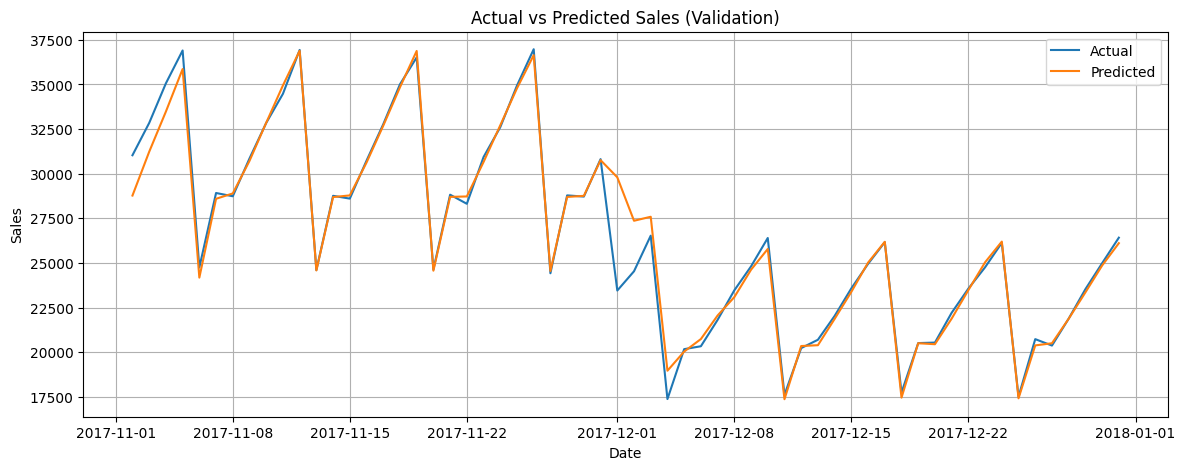

In [13]:
valid_plot = valid_data[["date", "sales"]].copy()
valid_plot["pred_sales"] = valid_pred

actual_daily = valid_plot.groupby("date")["sales"].sum()
pred_daily = valid_plot.groupby("date")["pred_sales"].sum()

plt.figure(figsize=(14,5))
plt.plot(actual_daily.index, actual_daily.values, label="Actual")
plt.plot(pred_daily.index, pred_daily.values, label="Predicted")
plt.title("Actual vs Predicted Sales (Validation)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 🚀 Step 11: Train Final Model & Predict for Test Data
Now train on ALL available training data and predict sales for test dates.

⚠️ Note:
To create lag features for test, we need the latest sales history.
We'll merge train+test dates per store/item and build lags.

In [14]:
# Combine train + test to create lag features for test
full = pd.concat([
    train[["date","store","item","sales"]],
    test.assign(sales=np.nan)[["date","store","item","sales"]]
], ignore_index=True)

full = add_time_features(full)
full = full.sort_values(["store","item","date"])

# create lag features on the combined frame
full["lag_1"] = full.groupby(["store","item"])["sales"].shift(1)
full["lag_7"] = full.groupby(["store","item"])["sales"].shift(7)
full["roll_mean_7"] = full.groupby(["store","item"])["sales"].shift(1).rolling(7).mean()

# split back
train_full = full[full["sales"].notna()].dropna().copy()
test_full = full[full["sales"].isna()].copy()

X_train_full = train_full[FEATURES]
y_train_full = train_full["sales"]

model_final = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
model_final.fit(X_train_full, y_train_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [15]:
# For rows where lags are NaN (if any), fill with simple values
# (This is a safe fallback; ideally, ensure enough history)
test_full[["lag_1","lag_7","roll_mean_7"]] = test_full[["lag_1","lag_7","roll_mean_7"]].fillna(0)

test_pred = model_final.predict(test_full[FEATURES])

test_full["sales_pred"] = test_pred
test_full.head()

,date,store,item,sales,year,month,day,dayofweek,is_weekend,lag_1,lag_7,roll_mean_7,sales_pred
913000,2018-01-01,1,1,NaN,2018,1,1,0,0,23.0,13.0,18.142857,15.713333
913001,2018-01-02,1,1,NaN,2018,1,2,1,0,0.0,16.0,0.000000,10.413333
913002,2018-01-03,1,1,NaN,2018,1,3,2,0,0.0,14.0,0.000000,10.196667
913003,2018-01-04,1,1,NaN,2018,1,4,3,0,0.0,19.0,0.000000,10.026667
913004,2018-01-05,1,1,NaN,2018,1,5,4,0,0.0,15.0,0.000000,8.966667


## 📦 Step 12: Create Submission File
We will fill `sample_submission.csv` with predictions and export as CSV.

In [16]:
submission = sub.copy()
submission["sales"] = test_full["sales_pred"].values

submission.to_csv("submission.csv", index=False)
submission.head()

,id,sales
0,0,15.713333
1,1,10.413333
2,2,10.196667
3,3,10.026667
4,4,8.966667


# ✅ Final Summary

### What we achieved:
- Loaded and cleaned a real-world demand dataset
- Performed time-series EDA
- Built time-based and lag features
- Trained a forecasting model
- Evaluated using MAE and RMSE
- Predicted future demand (test set)
- Exported `submission.csv`

### Next Improvements (Optional):
- Try XGBoost / LightGBM for higher accuracy
- Add more lags (14, 28) and rolling means (14, 30)
- Hyperparameter tuning
- Build Streamlit dashboard for business forecast output